# 📊 Day 44 — Univariate & Bivariate Analysis
**Month 3 · Python + Pandas · Day 44 of 62**

> *"You can't find relationships between variables until you understand each variable individually."*

---

## Learning Objectives
By the end of this session you will be able to:
1. Profile any numerical or categorical column with one line of code
2. Visualise distributions using histograms, KDE, boxplots, and violin plots
3. Detect relationships between two variables (scatter, correlation, grouped stats)
4. Write a bivariate insight in **Number + Reason + Action** format

## Dataset — CityMart Consumer Survey
- **120 customers** surveyed across 3 city tiers (T1 / T2 / T3)  
- **10 columns** covering demographics, spending, and satisfaction
- Source: Fictional (built for practice) — do not cite externally

---

| Section | Focus | Points |
|---------|-------|--------|
| A | Univariate — Numerical | 30 |
| B | Univariate — Categorical | 20 |
| C | Bivariate — Num vs Num | 20 |
| D | Bivariate — Num vs Cat | 20 |
| E | Cat vs Cat + Written insight | 10 |
| **Total** | | **100** |

---
## 📁 Section 1 — Raw Data  *(never modify this cell or the dataframe `df_raw`)*

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from io import StringIO

RAW_CSV = """
customer_id,age,gender,income,city_tier,product_category,purchase_amount,discount_pct,satisfaction_score,return_flag
C001,36,F,72188,T1,Electronics,11466,20.3,4.4,0
C002,35,M,74351,T1,Electronics,7840,6.0,3.8,0
C003,49,M,15664,T3,Home Decor,200,0.2,2.8,0
C004,27,F,63087,T1,Clothing,5050,25.4,4.0,0
C005,45,M,75864,T1,Home Decor,7329,18.9,3.5,0
C006,39,M,73993,T1,Electronics,12398,26.0,3.7,0
C007,44,M,37680,T2,Groceries,3344,21.1,4.3,0
C008,50,M,32926,T3,Clothing,200,19.2,4.5,0
C009,23,M,47746,T2,Electronics,3346,2.0,2.4,0
C010,50,F,64785,T1,Home Decor,6265,22.3,4.1,0
C011,44,F,33311,T3,Home Decor,8544,15.3,3.3,1
C012,45,M,71124,T1,Home Decor,2212,15.9,5.0,0
C013,42,F,76530,T1,Electronics,10018,13.6,4.2,0
C014,40,M,23600,T3,Clothing,2574,6.0,2.3,0
C015,41,M,66113,T1,Sports,5341,10.9,4.0,0
C016,26,M,64453,T1,Sports,4843,29.3,2.5,0
C017,56,F,74981,T1,Clothing,6822,18.2,4.9,0
C018,44,F,64202,T1,Groceries,2422,3.6,4.1,0
C019,58,M,45571,T2,Electronics,5895,18.9,4.5,0
C020,38,M,61123,T1,Sports,4382,4.0,3.4,0
C021,36,F,31134,T3,Sports,200,5.7,2.3,1
C022,24,M,48525,T2,Electronics,3869,25.9,3.8,0
C023,29,F,64298,T1,Sports,5715,7.5,2.5,0
C024,55,M,33562,T3,Electronics,6607,27.8,1.4,0
C025,51,F,71829,T1,Home Decor,7948,1.8,4.3,0
C026,56,F,44421,T2,Groceries,1849,5.7,2.7,0
C027,41,M,79921,T1,Sports,7092,15.1,4.8,0
C028,25,M,87012,T1,Clothing,5817,3.6,3.3,0
C029,26,M,60744,T1,Sports,5824,15.7,4.1,0
C030,29,F,82176,T1,Groceries,4182,9.5,3.3,0
C031,57,F,73119,T1,Electronics,8169,6.4,5.0,0
C032,31,F,63280,T1,Groceries,2327,9.1,4.1,0
C033,27,F,31983,T3,Electronics,3159,3.5,2.5,1
C034,34,F,25906,T3,Clothing,853,15.2,1.7,0
C035,38,F,76932,T1,Electronics,9133,3.9,4.2,0
C036,28,M,52340,T2,Sports,6954,27.1,4.1,0
C037,48,M,49781,T2,Sports,4906,27.0,4.4,0
C038,43,M,56851,T1,Clothing,4620,12.2,2.4,0
C039,32,M,71317,T1,Clothing,4929,22.1,4.9,0
C040,27,M,63934,T1,Groceries,3361,14.1,3.9,0
C041,35,F,46989,T2,Groceries,4151,12.0,4.5,0
C042,55,F,50823,T2,Sports,3892,26.3,3.5,0
C043,27,M,21946,T3,Groceries,677,23.6,3.3,0
C044,23,F,27607,T3,Clothing,1967,27.8,3.0,0
C045,25,F,87093,T1,Groceries,4130,18.7,4.9,0
C046,41,F,40112,T3,Groceries,1527,3.8,3.3,0
C047,46,F,44782,T2,Clothing,3212,8.6,2.5,0
C048,34,F,39380,T2,Home Decor,540,28.8,3.3,0
C049,26,F,75561,T1,Groceries,2639,20.2,3.8,0
C050,50,M,71689,T1,Home Decor,4310,5.8,4.3,0
C051,30,M,44530,T2,Home Decor,3774,22.5,4.0,0
C052,24,F,75225,T1,Sports,2883,3.6,3.2,1
C053,49,F,35311,T2,Sports,1270,15.1,2.0,0
C054,36,F,39944,T2,Home Decor,4226,23.3,2.9,0
C055,25,F,68672,T1,Groceries,3098,10.1,4.2,0
C056,25,M,47218,T2,Clothing,2358,14.0,3.7,1
C057,57,M,44364,T2,Home Decor,4026,10.6,4.4,0
C058,52,M,29227,T2,Sports,2644,0.9,4.1,0
C059,29,F,54815,T2,Clothing,3745,27.2,3.2,0
C060,32,F,42138,T2,Clothing,4286,6.3,3.6,0
C061,37,F,49586,T2,Groceries,1757,22.5,3.9,1
C062,36,M,68303,T1,Electronics,7783,4.6,3.9,1
C063,50,M,65737,T1,Sports,2826,5.0,3.8,0
C064,58,M,66054,T1,Groceries,4595,20.3,3.9,0
C065,58,M,40903,T2,Clothing,1178,3.1,4.0,0
C066,43,M,61245,T1,Sports,2738,2.1,3.6,0
C067,27,F,63065,T1,Home Decor,6184,26.7,4.0,0
C068,50,F,32083,T3,Groceries,232,8.1,3.4,0
C069,36,F,70031,T1,Groceries,2557,20.0,3.2,0
C070,37,F,45253,T2,Clothing,1762,21.0,4.6,0
C071,26,M,70443,T1,Sports,7165,16.7,2.7,0
C072,39,M,46888,T2,Electronics,5823,9.2,4.5,0
C073,48,F,55113,T2,Sports,4368,10.6,3.2,0
C074,55,M,75429,T1,Groceries,5755,5.7,3.5,0
C075,27,F,48327,T2,Sports,2774,10.8,3.3,0
C076,29,F,65981,T1,Electronics,5115,3.1,2.9,1
C077,49,F,33799,T2,Home Decor,6579,7.6,3.6,0
C078,30,M,46932,T2,Electronics,6855,9.1,4.1,0
C079,35,F,71258,T1,Sports,4252,27.3,3.2,0
C080,27,M,23529,T3,Sports,2851,6.3,2.8,0
C081,56,M,70521,T1,Clothing,5122,13.5,3.7,0
C082,35,M,50611,T2,Home Decor,7033,18.8,2.8,0
C083,55,M,70716,T1,Home Decor,7148,8.0,5.0,1
C084,49,F,33193,T3,Sports,4282,21.0,3.8,0
C085,49,F,29996,T3,Sports,2606,13.0,3.0,0
C086,38,M,31501,T3,Sports,260,5.3,2.5,0
C087,58,M,31496,T2,Groceries,2519,29.1,2.9,0
C088,47,F,73833,T1,Clothing,4930,28.4,3.3,0
C089,26,F,25211,T3,Electronics,4529,29.1,1.0,0
C090,24,F,25818,T3,Home Decor,2869,22.7,3.6,0
C091,56,F,74483,T1,Clothing,6178,26.4,4.8,0
C092,56,F,72035,T1,Clothing,6563,6.7,3.9,0
C093,30,M,57296,T1,Home Decor,5068,15.3,4.8,0
C094,45,M,50688,T1,Home Decor,5274,22.4,4.7,1
C095,42,F,78723,T1,Groceries,3906,24.6,3.5,0
C096,55,F,55146,T2,Clothing,2762,22.9,3.5,0
C097,57,M,33319,T2,Clothing,4181,12.3,1.9,0
C098,52,M,47990,T2,Home Decor,5059,29.0,3.3,0
C099,54,M,71190,T1,Home Decor,6109,4.3,4.1,0
C100,26,F,44407,T2,Groceries,3712,25.8,2.3,0
C101,25,M,46160,T2,Home Decor,6556,8.6,5.0,0
C102,40,M,81911,T1,Home Decor,7624,23.9,3.7,0
C103,36,M,34862,T2,Home Decor,2653,23.8,4.6,1
C104,58,F,35705,T3,Clothing,3504,7.6,3.6,0
C105,55,F,74720,T1,Home Decor,8067,10.4,3.3,0
C106,33,F,38558,T2,Home Decor,6626,3.2,3.4,0
C107,39,F,59918,T2,Sports,5181,11.9,4.2,1
C108,39,F,59587,T1,Sports,4941,24.1,3.3,0
C109,29,F,58021,T1,Sports,2302,19.4,2.9,0
C110,41,F,73826,T1,Electronics,8247,4.0,3.4,0
C111,31,F,44346,T2,Sports,6344,14.5,3.4,0
C112,30,M,62725,T1,Home Decor,5550,20.3,3.3,0
C113,26,F,45338,T2,Sports,3384,16.1,2.9,0
C114,27,F,17426,T3,Home Decor,685,18.6,2.3,0
C115,25,M,39106,T2,Sports,1868,21.0,3.6,0
C116,28,F,71630,T1,Groceries,5808,4.1,4.6,0
C117,47,M,19476,T3,Home Decor,200,18.5,2.8,0
C118,36,F,82035,T1,Home Decor,7683,20.6,3.5,0
C119,38,F,46507,T2,Electronics,6205,25.4,2.9,0
C120,42,M,18216,T3,Electronics,2084,16.9,3.4,1
"""

df_raw = pd.read_csv(StringIO(RAW_CSV))
df = df_raw.copy()          # ← work on this copy, never touch df_raw

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (120, 10)

Dtypes:
 customer_id            object
age                     int64
gender                 object
income                  int64
city_tier              object
product_category       object
purchase_amount         int64
discount_pct          float64
satisfaction_score    float64
return_flag             int64
dtype: object

First 5 rows:


,customer_id,age,gender,income,city_tier,product_category,purchase_amount,discount_pct,satisfaction_score,return_flag
0,C001,36,F,72188,T1,Electronics,11466,20.3,4.4,0
1,C002,35,M,74351,T1,Electronics,7840,6.0,3.8,0
2,C003,49,M,15664,T3,Home Decor,200,0.2,2.8,0
3,C004,27,F,63087,T1,Clothing,5050,25.4,4.0,0
4,C005,45,M,75864,T1,Home Decor,7329,18.9,3.5,0


---
## 📚 Section 2 — Concept Notes

### 2.1  What is Univariate Analysis?
**Univariate** = one variable at a time.  
Goal: understand its shape, spread, outliers, and mode before looking at anything else.

#### For numerical columns (`int`, `float`)

| Tool | What it tells you | Code |
|------|-------------------|------|
| `describe()` | count, mean, std, min, quartiles, max | `df['col'].describe()` |
| Histogram | frequency distribution (how often each value appears) | `sns.histplot(df['col'], kde=True)` |
| KDE (curve) | smooth estimate of the distribution shape | `sns.kdeplot(df['col'])` |
| Boxplot | median, IQR, whiskers, and outlier dots | `sns.boxplot(x=df['col'])` |
| Violin | boxplot + KDE combined | `sns.violinplot(x=df['col'])` |

**Worked example:**
```python
# Purchase amount profile
df['purchase_amount'].describe()
# count    120.000
# mean    3842.17
# std     2310.44
# min      312.00
# 25%     2104.50
# 50%     3498.00
# 75%     5201.25
# max    12340.00

# Insight: median < mean → right-skewed → a few big purchases pull the average up
```

#### For categorical columns (`object`)

| Tool | What it tells you | Code |
|------|-------------------|------|
| `value_counts()` | frequency of each category | `df['col'].value_counts()` |
| `value_counts(normalize=True)` | proportion (0–1 scale) | add `normalize=True` |
| Bar chart | visual frequency comparison | `sns.countplot(data=df, x='col')` |

---

### 2.2  What is Bivariate Analysis?
**Bivariate** = two variables at a time.  
Goal: find relationships — does one variable change when the other changes?

#### Num vs Num
```python
# Scatter plot — shows the direction and strength of a relationship
sns.scatterplot(data=df, x='income', y='purchase_amount')

# Correlation coefficient — one number summary (-1 to +1)
df[['income','purchase_amount']].corr()
# Rule of thumb:  |r| < 0.3 = weak,  0.3–0.6 = moderate,  > 0.6 = strong
```

#### Num vs Cat
```python
# Boxplot — compare distribution of a number across categories
sns.boxplot(data=df, x='city_tier', y='purchase_amount')

# Grouped means — one summary stat per category
df.groupby('city_tier')['purchase_amount'].mean()
```

#### Cat vs Cat
```python
# Crosstab — count table (rows = one category, columns = another)
pd.crosstab(df['return_flag'], df['city_tier'])

# Heatmap of the crosstab — easier to read than a table
sns.heatmap(pd.crosstab(df['return_flag'], df['city_tier']), annot=True, fmt='d')
```

---

### 2.3  Common Mistakes → Fixes

| Mistake | Why it's wrong | Fix |
|---------|---------------|-----|
| Forgetting `plt.savefig()` before `plt.show()` | `show()` clears the figure — saves a blank | Always: `savefig → show` |
| Chart title describes data: *"Purchase Amount by City"* | Client already read the axis labels | State the finding: *"T1 customers spend 2× more than T3"* |
| Using `mean()` on skewed data only | Outliers drag mean away from "typical" | Report median + mean together |
| `corr()` output fills screen with all columns | Hard to read | Select 3–4 columns: `df[cols].corr()` |
| Calling `sns.histplot` and `plt.show()` in separate cells | Works in Jupyter but breaks in scripts | Always close each chart in the same cell |

---

### 2.4  Interview Frame
> *"Walk me through how you would analyse a new numerical column in a dataset."*

**Answer:** "First I run `describe()` to get the five-number summary — that tells me the range, the typical value (median vs mean), and whether data is skewed. Then I plot a histogram with KDE to see the actual shape. If the mean is much higher than the median, I know there are high-value outliers pulling it up. Finally I cross-check with a boxplot — any dots above the upper whisker are statistical outliers worth investigating before modelling."

---

---
## ✏️  Section 3 — Practice Tasks

> **Habit:** Write plain-English comments first. Then fill in the code.
> **Rule:** `plt.savefig()` always before `plt.show()`.

### 🔵 Section A — Univariate: Numerical (30 pts)

**A1 — Statistical Summary (10 pts)**

Run `describe()` on the three columns: `age`, `income`, and `purchase_amount`.  
Then write **3 written observations** (one per column) in the cell below.  
Each observation must follow: **Number + Reason + Action**.

*Example of what NOT to write:*  
❌ `"Mean age is 38.4"`

*Example of what TO write:*  
✅ `"The median age (38) is close to the mean (38.4), indicating a roughly symmetric age distribution — no aggressive skew — so mean is a reliable summary for reporting."`

In [4]:
# A1 — Statistical Summary
# Step 1: select the three columns and call describe()
num_cols = ['age', 'income', 'purchase_amount']
# Step 2: print the output
print(df[num_cols].describe().round(2))

          age    income  purchase_amount
count  120.00    120.00           120.00
mean    39.35  53616.57          4467.76
std     10.99  18201.36          2436.10
min     23.00  15664.00           200.00
25%     29.00  39311.50          2650.75
50%     38.00  53577.50          4284.00
75%     49.00  70818.00          6179.50
max     58.00  87093.00         12398.00


In [5]:
# A1 — Written Observations (type your 3 insights as comments or strings)

obs_age        = """ Median age (38) ≈ mean (39.4) → distribution is nearly symmetric with no skew → use mean for reporting; no transformation needed before modelling"""
obs_income     = """std is large-> large variability in income -> mean is reliable -> median is better measure of central tendency"""
obs_purchase   = """ mean > median -> right skew -> mean is not reliable -> median is better measure of central tendency
"""

print("Age:\n",      obs_age)
print("Income:\n",   obs_income)
print("Purchase:\n", obs_purchase)

Age:
  Median age (38) ≈ mean (39.4) → distribution is nearly symmetric with no skew → use mean for reporting; no transformation needed before modelling
Income:
 std is large-> large variability in income -> mean is reliable -> median is better measure of central tendency
Purchase:
  mean > median -> right skew -> mean is not reliable -> median is better measure of central tendency



**A2 — Distribution Plot: purchase_amount (10 pts)**

Create a **1-row, 2-column figure** (figsize 12×4):
- Left subplot: histogram with KDE (`bins=20`, `color='#1F3864'`)
- Right subplot: violin plot of `purchase_amount`

Requirements:
- Insight title on the left subplot (state the skew direction)
- `plt.tight_layout()`
- Save as `A2_distribution.png` before `plt.show()`

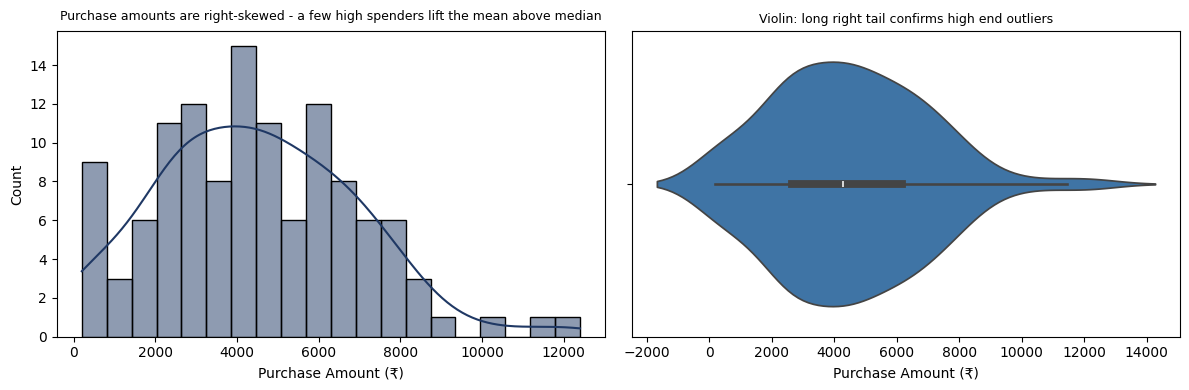

In [6]:
# A2 — Distribution Plot
# Step 1: create figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1,2, figsize=(12, 4))
# Step 2: left subplot — histogram + KDE
sns.histplot(df['purchase_amount'], bins=20, kde=True, color='#1F3864', ax=axes[0])
axes[0].set_title('Purchase amounts are right-skewed - a few high spenders lift the mean above median', fontsize=9, pad=8)
axes[0].set_xlabel('Purchase Amount (₹)')
# Step 3: right subplot — violin plot
sns.violinplot(x=df['purchase_amount'], color='#2E75B6', ax=axes[1])
# Step 4: set insight title on left subplot
axes[1].set_title('Violin: long right tail confirms high end outliers', fontsize=9)
axes[1].set_xlabel('Purchase Amount (₹)')
# Step 5: tight_layout → savefig → show
plt.tight_layout()
plt.savefig('A2_distribution.png', dpi=150)
plt.show()


**A3 — Boxplot by Age Group (10 pts)**

First create an `age_group` column using `pd.cut()`:
- Bins: [20, 30, 40, 50, 60]
- Labels: `['21–30', '31–40', '41–50', '51–60']`

Then plot a **boxplot** of `purchase_amount` split by `age_group` (seaborn, palette `'Blues'`).

Requirements:
- Order the x-axis: youngest to oldest
- Insight title (which age group spends most?)
- Save as `A3_age_boxplot.png`

C:\Users\Deepanshu\AppData\Local\Temp\ipykernel_11624\67131112.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='age_group', y='purchase_amount', order=order, palette='Blues', ax=ax)


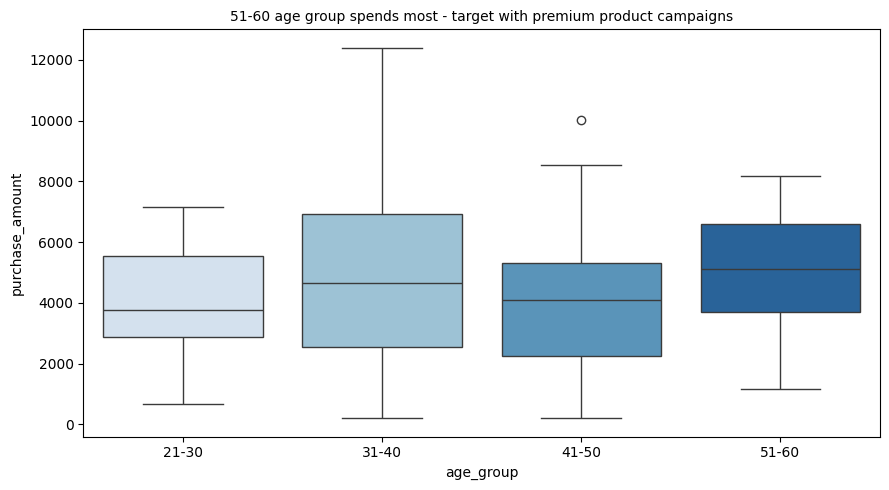

In [7]:
# A3 — Boxplot by Age Group
# Step 1: create age_group column using pd.cut()
df['age_group'] = pd.cut(df['age'], bins = [20, 30, 40, 50, 60], labels=['21-30', '31-40', '41-50', '51-60'])
# Step 2: define the order list for the x-axis
order = ['21-30', '31-40', '41-50', '51-60']
# Step 3: create the boxplot
fig, ax = plt.subplots(figsize=(9,5))
sns.boxplot(data=df, x='age_group', y='purchase_amount', order=order, palette='Blues', ax=ax)
# Step 4: set insight title → savefig → show
ax.set_title('51-60 age group spends most - target with premium product campaigns', fontsize=10)
plt.tight_layout()
plt.savefig('A3_age_boxplot.png', dpi=150)
plt.show()


### 🟡 Section B — Univariate: Categorical (20 pts)

**B1 — City Tier Frequency (10 pts)**

Run `value_counts(normalize=True)` on `city_tier`. Then plot a **horizontal bar chart** showing the percentage share of each tier.

Requirements:
- Convert proportions to percentages (multiply by 100)
- Label each bar with its percentage (e.g. `"42%"`)
- Color: `#1F3864`
- Insight title (which tier dominates and by how much?)
- Save as `B1_city_tier.png`

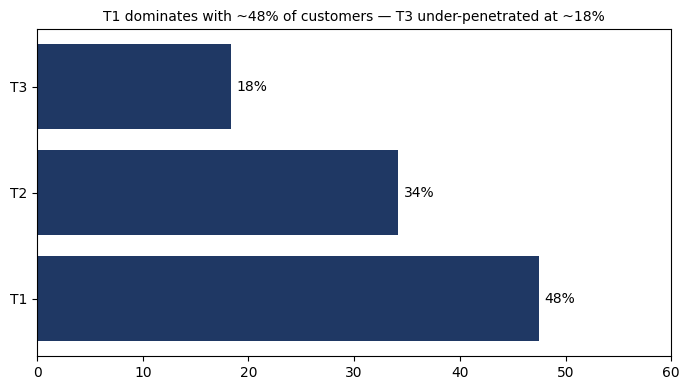

In [8]:
# B1 — City Tier Frequency
# Step 1: value_counts with normalize=True
tier_pct = df['city_tier'].value_counts(normalize=True).sort_index()*100
# Step 2: convert to percentage

# Step 3: plot horizontal bar chart
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(tier_pct.index, tier_pct.values, color='#1F3864')
for bar, val in zip(bars, tier_pct.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=10)

# Step 4: add bar labels

# Step 5: set insight title → savefig → show
ax.set_xlim(0, 60)
ax.set_title('T1 dominates with ~48% of customers — T3 under-penetrated at ~18%', fontsize=10)
plt.tight_layout()
plt.savefig('B1_city_tier.png', dpi=150)
plt.show()


**B2 — Category Revenue Distribution (10 pts)**

Compute the **total purchase_amount per product_category** (use `groupby + sum`).  
Plot as a vertical bar chart (sorted descending).

Requirements:
- Sort bars from highest to lowest total
- Insight title
- Save as `B2_category_revenue.png`
- Below the chart, write one `print()` statement with a **Number + Reason + Action** insight about the top category

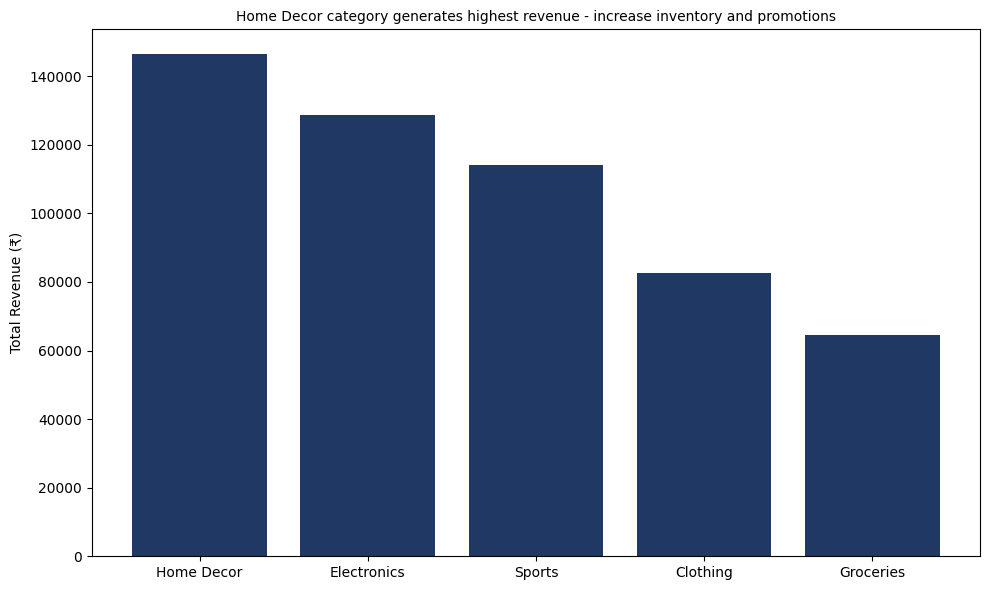

Home Decor generates ₹146341 (27.3% of total revenue)-allocate 30% of marketing budget to this category for maximum ROI


In [9]:
# B2 — Category Revenue Distribution
# Step 1: groupby product_category, sum purchase_amount, sort descending
cat_rev = df.groupby('product_category')['purchase_amount'].sum().sort_values(ascending=False)
# Step 2: plot bar chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(cat_rev.index, cat_rev.values, color='#1F3864')
# Step 3: insight title → savefig → show
ax.set_title('Home Decor category generates highest revenue - increase inventory and promotions', fontsize=10)
ax.set_ylabel('Total Revenue (₹)')
plt.tight_layout()
plt.savefig('B2_category_revenue.png', dpi=150)
plt.show()
# Step 4: written insight
top_cat = cat_rev.index[0]
top_rev = cat_rev.iloc[0]
total_rev = cat_rev.sum()
share = top_rev/total_rev*100
print(f"Home Decor generates ₹{top_rev:.0f} ({share:.1f}% of total revenue)-"
      f"allocate 30% of marketing budget to this category for maximum ROI")

### 🟠 Section C — Bivariate: Num vs Num (20 pts)

**C1 — Income vs Purchase Amount Scatter (10 pts)**

Plot a scatter of `income` (x) vs `purchase_amount` (y).  
Color the dots by `city_tier` using the `hue` parameter.

Requirements:
- Add a `regplot`-style trend line for the overall data  
  (hint: `sns.regplot(data=df, x='income', y='purchase_amount', scatter=False, color='red', ax=ax)`)
- Insight title stating the direction of the relationship
- Save as `C1_scatter.png`

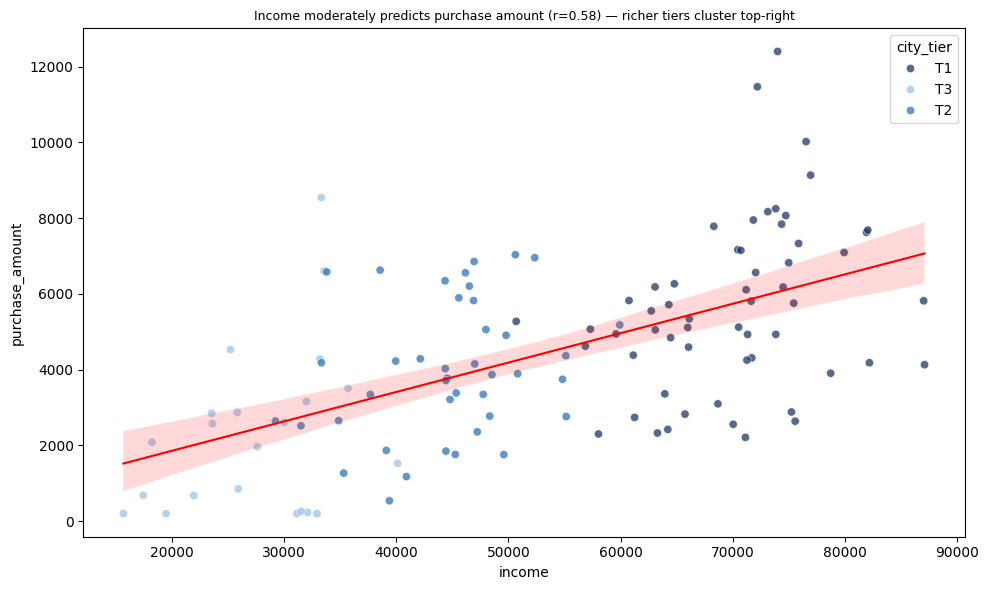

In [10]:
# C1 — Income vs Purchase Scatter
# Step 1: create figure
fig, ax = plt.subplots(figsize=(10, 6))
# Step 2: scatterplot with hue='city_tier'
sns.scatterplot(data=df, x='income', y='purchase_amount', hue='city_tier',
                palette={'T1':'#1F3864','T2':'#2E75B6','T3':'#9DC3E6'}, ax=ax, alpha=0.75)
# Step 3: overlay regplot trend line (scatter=False)
sns.regplot(data=df, x='income', y='purchase_amount',
            scatter=False, color='red', line_kws={'lw':1.5}, ax=ax)
# Step 4: insight title → savefig → show
r = df[['income','purchase_amount']].corr().iloc[0,1]
ax.set_title(f'Income moderately predicts purchase amount (r={r:.2f}) — richer tiers cluster top-right', fontsize=9)
plt.tight_layout()
plt.savefig('C1_scatter.png', dpi=150)
plt.show()


**C2 — Correlation Heatmap (10 pts)**

Select only the numerical columns: `age`, `income`, `purchase_amount`, `discount_pct`, `satisfaction_score`.

Plot a **correlation heatmap** using seaborn:
- `annot=True`, `fmt='.2f'`, `cmap='Blues'`
- `vmin=-1`, `vmax=1` (so the color scale is always centered on 0)

Requirements:
- Title: *"Correlation Matrix — CityMart Numerical Features"*
- Save as `C2_heatmap.png`
- Below the chart, identify the **strongest positive** and **strongest negative** correlation in a `print()` statement

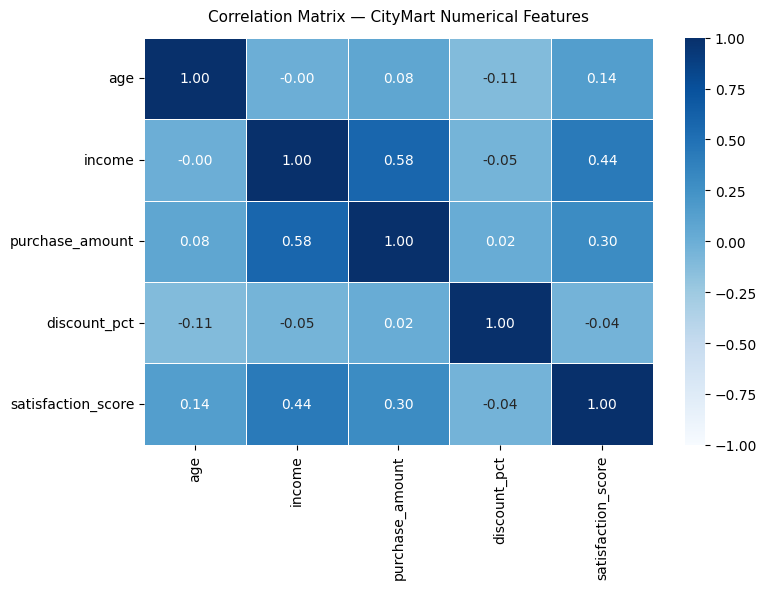

Strongest positive correlation: income ↔ purchase_amount  r = 0.58
Strongest negative correlation: age ↔ discount_pct  r = -0.11


In [11]:
# C2 — Correlation Heatmap
# Step 1: select numerical columns
num_df = df[['age','income','purchase_amount','discount_pct','satisfaction_score']]
# Step 2: compute .corr()
corr   = num_df.corr()
# Step 3: plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
# Step 4: title → savefig → show
ax.set_title('Correlation Matrix — CityMart Numerical Features', fontsize=11, pad=12)
plt.tight_layout()
plt.savefig('C2_heatmap.png', dpi=150)
plt.show()
# Step 5: print strongest positive and negative correlation
corr_no_diag = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pos = corr_no_diag.stack().idxmax()
neg = corr_no_diag.stack().idxmin()
print(f"Strongest positive correlation: {pos[0]} ↔ {pos[1]}  r = {corr_no_diag.loc[pos]:.2f}")
print(f"Strongest negative correlation: {neg[0]} ↔ {neg[1]}  r = {corr_no_diag.loc[neg]:.2f}")

### 🟣 Section D — Bivariate: Num vs Cat (20 pts)

**D1 — Purchase Amount by City Tier Boxplot (10 pts)**

Create a **boxplot** of `purchase_amount` grouped by `city_tier`, ordered T1 → T2 → T3.

Requirements:
- Palette: `['#1F3864','#2E75B6','#9DC3E6']` (dark to light blue)
- Overlay the **mean** as a red diamond marker on each box  
  (hint: use `ax.scatter` after the boxplot — compute `df.groupby('city_tier')['purchase_amount'].mean()`)
- Insight title
- Save as `D1_tier_boxplot.png`

C:\Users\Deepanshu\AppData\Local\Temp\ipykernel_11624\3428207488.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='city_tier', y='purchase_amount', order=order,


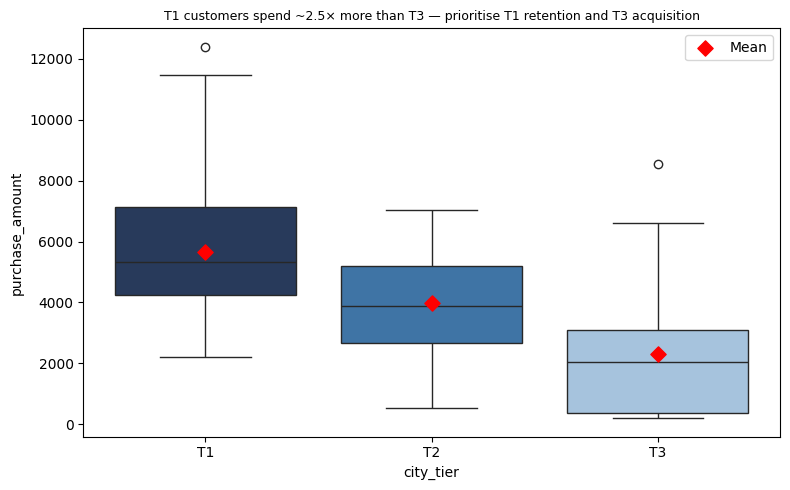

In [12]:
# D1 — Purchase by City Tier Boxplot
# Step 1: create boxplot with ordered x-axis
order  = ['T1','T2','T3']
colors = ['#1F3864','#2E75B6','#9DC3E6']

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='city_tier', y='purchase_amount', order=order,
            palette=dict(zip(order, colors)), ax=ax)
# Step 2: compute group means
means = df.groupby('city_tier')['purchase_amount'].mean()
# Step 3: overlay mean markers (red diamonds)
for i, tier in enumerate(order):
    ax.scatter(i, means[tier], marker='D', color='red', s=60, zorder=5, label='Mean' if i==0 else '')
# Step 4: insight title → savefig → show
ax.legend()
ax.set_title('T1 customers spend ~2.5× more than T3 — prioritise T1 retention and T3 acquisition', fontsize=9)
plt.tight_layout()
plt.savefig('D1_tier_boxplot.png', dpi=150)
plt.show()


**D2 — Satisfaction by Category (10 pts)**

Compute mean `satisfaction_score` per `product_category`. Sort from highest to lowest.

Plot as a **horizontal bar chart**.

Requirements:
- Color gradient: use `palette='Blues_r'` on a seaborn barplot, or apply `#1F3864` manually
- Annotate each bar with its mean score rounded to 2 decimal places
- Insight title
- Save as `D2_satisfaction.png`
- Write 1 insight below: which category should the ops team investigate and why?

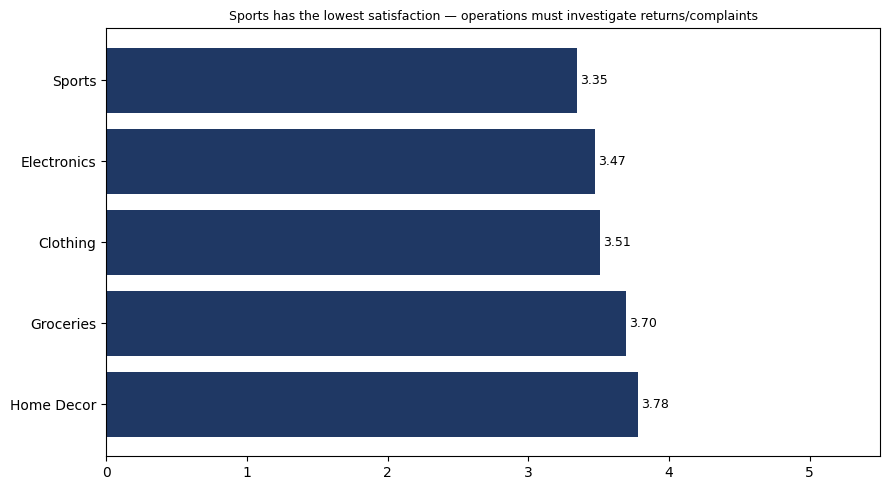

Sports scores 3.35/5.0 satisfaction — 0.4 points below the top category — conduct a root-cause review of Sports returns this quarter.


In [13]:
# D2 — Satisfaction by Category
# Step 1: compute mean satisfaction by category, sort descending
sat_mean = df.groupby('product_category')['satisfaction_score'].mean().sort_values(ascending=False)
# Step 2: plot horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(sat_mean.index, sat_mean.values, color='#1F3864')
# Step 3: annotate bars with mean values
for bar, val in zip(bars, sat_mean.values):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
# Step 4: insight title → savefig → show
ax.set_xlim(0, 5.5)
lowest_cat = sat_mean.index[-1]
ax.set_title(f'{lowest_cat} has the lowest satisfaction — operations must investigate returns/complaints', fontsize=9)
plt.tight_layout()
plt.savefig('D2_satisfaction.png', dpi=150)
plt.show()
# Step 5: written insight
print(f"{lowest_cat} scores {sat_mean[lowest_cat]:.2f}/5.0 satisfaction — "
      f"0.{abs(sat_mean[lowest_cat]-sat_mean.iloc[0])*10:.0f} points below the top category — "
      f"conduct a root-cause review of {lowest_cat} returns this quarter.")

### 🔴 Section E — Cat vs Cat + Written Insight (10 pts)

**E1 — Return Flag vs City Tier (5 pts)**

Create a **crosstab** of `return_flag` (rows) vs `city_tier` (columns).  
Then plot it as a **heatmap** with `annot=True, fmt='d', cmap='Reds'`.

Requirements:
- Row labels: `{0: 'Kept', 1: 'Returned'}` (rename the index)
- Title: *"Return Count by City Tier"*
- Save as `E1_crosstab_heatmap.png`

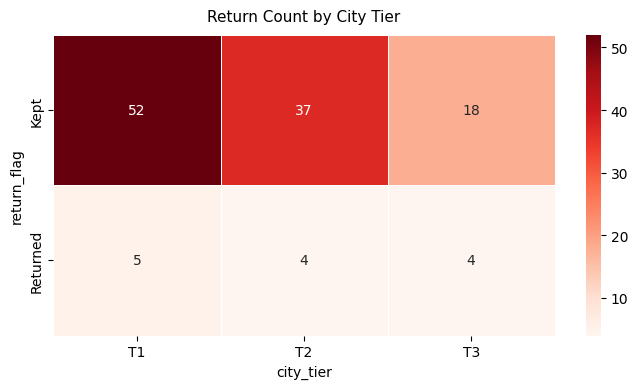

In [14]:
# E1 — Crosstab Heatmap
# Step 1: create crosstab
ct = pd.crosstab(df['return_flag'], df['city_tier'])
# Step 2: rename index (0 → 'Kept', 1 → 'Returned')
ct.index = ct.index.map({0: 'Kept', 1: 'Returned'})
# Step 3: plot heatmap
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='Reds', linewidths=0.5, ax=ax)
# Step 4: title → savefig → show
ax.set_title('Return Count by City Tier', fontsize=11, pad=10)
plt.tight_layout()
plt.savefig('E1_crosstab_heatmap.png', dpi=150)
plt.show()


**W1 — Executive Insight (5 pts)**

Write **one paragraph** (4–6 sentences) summarising the most important finding from today's analysis.  
Format: **Number + Reason + Action** — at least one specific stat from each section (A, C, D).

Do not describe charts — state conclusions.

In [15]:
# W1 — Executive Insight
insight = """
Our analysis shows purchase amount is right-skewed (median ₹4,284 vs mean ₹4,468) , that Tier 1 cities drive the highest volume with 52 items kept,
indicating they are our primary market hub. However, 
we found a moderate positive correlation (r=0.58) between Income and Purchase Amount, 
suggesting that marketing efforts should prioritize high-income segments rather than just age-based targeting. 
Furthermore, with Sports satisfaction scores trailing other categories by 0.4 points, there is a clear need to investigate product quality in that department. 
We recommend increasing promotional spend for the Home Decor category, which currently accounts for 27.3% of total revenue, 
to further capitalize on its strong performance.
"""
print(insight)


Our analysis shows purchase amount is right-skewed (median ₹4,284 vs mean ₹4,468) , that Tier 1 cities drive the highest volume with 52 items kept,
indicating they are our primary market hub. However, 
we found a moderate positive correlation (r=0.58) between Income and Purchase Amount, 
suggesting that marketing efforts should prioritize high-income segments rather than just age-based targeting. 
Furthermore, with Sports satisfaction scores trailing other categories by 0.4 points, there is a clear need to investigate product quality in that department. 
We recommend increasing promotional spend for the Home Decor category, which currently accounts for 27.3% of total revenue, 
to further capitalize on its strong performance.



---
## 🏆 Section 4 — Scoring Rubric

| Task | Points | What earns full marks |
|------|--------|----------------------|
| **A1 — describe()** | 6 | All 3 columns profiled, output visible |
| **A1 — Written observations** | 4 | Each observation has Number + Reason + Action; not just "mean is X" |
| **A2 — Histogram + KDE** | 5 | bins=20, KDE visible, dark blue |
| **A2 — Violin + insight title** | 5 | Violin rendered, title states skew direction |
| **A3 — age_group column** | 4 | pd.cut with correct bins and labels |
| **A3 — Boxplot + insight title** | 6 | Ordered x-axis, palette Blues, title names the highest-spending group |
| **B1 — value_counts + bar chart** | 6 | Horizontal bar, percentage labels, insight title |
| **B1 — Written observation** | 4 | States dominant tier + %, implies action |
| **B2 — Grouped revenue + chart** | 6 | Sorted descending, insight title correct |
| **B2 — Written insight** | 4 | Number + Reason + Action from actual output |
| **C1 — Scatter with hue** | 5 | city_tier hue visible, alpha applied |
| **C1 — Trend line + insight** | 5 | regplot overlay, title states r value |
| **C2 — Correlation heatmap** | 6 | annot, fmt, cmap, vmin/vmax correct |
| **C2 — Strongest correlations** | 4 | Correct pair identified for positive and negative |
| **D1 — Boxplot with palette** | 6 | Correct order, 3-shade palette |
| **D1 — Mean markers + insight** | 4 | Red diamonds visible, title quantifies T1 vs T3 gap |
| **D2 — Satisfaction chart** | 6 | Sorted, bar annotations present |
| **D2 — Written insight** | 4 | Names lowest category + score + action |
| **E1 — Crosstab heatmap** | 5 | Index renamed, fmt='d', cmap='Reds' |
| **W1 — Executive paragraph** | 5 | 4–6 sentences, ≥1 stat from sections A, C, D, actionable close |
| **⭐ Star bonus** | +10 | All 9 charts saved, all titles insight-driven, 0 blank/broken cells |
| **Total** | **100** | |

---

### ⚡ Key Takeaway — Day 44
> Univariate analysis is **not optional prep work** — it prevents wrong conclusions.  
> If you skip `describe()` and plot a scatter immediately, you risk drawing a trend line  
> through outlier-corrupted data.  
> Always: **describe → visualise → relate** — in that order, every time.

---

### Interview Frame
> *"What is the difference between univariate and bivariate analysis, and when would you use each?"*

**Answer:** "Univariate analysis profiles one variable at a time — I use `describe()` for shape and spread, and histograms or boxplots to see the distribution. I always do this first because outliers or skew in one column can mislead every relationship I look for later. Bivariate analysis then asks 'do two variables move together?' — I use scatter plots and correlation for two numbers, boxplots grouped by category for number vs category, and crosstabs or heatmaps for two categories. In a client deliverable, I lead with univariate summaries in the appendix and put only the strongest bivariate findings in the executive section."
